In [1]:
import dill

# first looking at the process tensors generated from non-analytical code


parameter_set = {"1K, alpha=0.1":[0.25,8.0,50],
                 "1K, alpha=0.05":[0.25,8.0,30],
                 "10K, alpha=0.1":[0.2,6.0,30]}


params = parameter_set["1K, alpha=0.1"]

# 1K , alpha=0.1 
file_name1='results/processtensors/processtensorcf_dt={0}_ps=-{1}_tcut={2}'.format(params[0],params[1],params[2])
with open(file_name1,'rb') as f:
    pt_1K=dill.load(f)

params = parameter_set["1K, alpha=0.05"]

# 1K , lower coupling
file_name1='results/processtensors_lowercoupling/processtensorcf_dt={0}_ps=-{1}_tcut={2}_alpha=0.05'.format(params[0],params[1],params[2])
with open(file_name1,'rb') as f:
    pt_1K_lowercoupling=dill.load(f)

params = parameter_set["10K, alpha=0.1"]

# 10K , alpha=0.1
file_name1='results/processtensors_10K/processtensorcf_dt={0}_ps=-{1}_tcut={2}'.format(params[0],params[1],params[2])
with open(file_name1,'rb') as f:
    pt_10K=dill.load(f)

In [6]:
import numpy as np
bond_dims_1=[]
bond_dims_2=[]

proc_tensors=[pt_1K, pt_1K_lowercoupling, pt_10K]

for pt in proc_tensors:
    bond_dims_1.append(np.shape(pt.get_mpo_tensor(0))[1])
    bond_dims_2.append(np.shape(pt.get_mpo_tensor(1))[1])

print(bond_dims_1)
print(bond_dims_2)

[2011, 501, 498]
[2011, 501, 498]


In [ ]:
import oqupy
from oqupy.tti_tempo import TTITempo, TTITempoCounting
from oqupy import operators as op


params = parameter_set["1K, alpha=0.1"]


dt = params[0]
print(dt)
epsrel_pow = int(params[1])
epsrel = 10**(-epsrel_pow)  # convert to float
tcut= 500  # tcut (int)

pt_parameters = {'epsrel':epsrel,
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131,
                 'dt':dt,
                 'tcut':tcut}


omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']

tcut=pt_parameters['tcut']

Rho_0=oqupy.operators.spin_dm("x+")

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w

correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)

u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD_analytical(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

#num_steps=int(t_arg/dt)

pt= TTITempo(bath,start_time=0.0,parameters=parameters)
processtensor= pt.get_process_tensor()

pt_cf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
processtensorcf = pt_cf.get_process_tensor()

0.25


building influence functional:   0%|          | 0/2001 [00:00<?, ?it/s]

building influence functional: 100%|██████████| 2001/2001 [00:01<00:00, 1043.81it/s]


rank  46


building influence functional: 100%|██████████| 2001/2001 [00:01<00:00, 1378.38it/s]

rank  48


In [45]:
import os 
print(dt,epsrel)
folder="results/processtensors_lowercoupling"
# optimization result
file_name1=os.path.join(folder,'processtensor_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
with open(file_name1,'wb') as f:
    dill.dump(processtensor,f)

file_name1=os.path.join(folder,'processtensorCF_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
with open(file_name1,'wb') as f:
    dill.dump(processtensorcf,f)

0.25 1e-08


In [65]:
100//dt

400.0

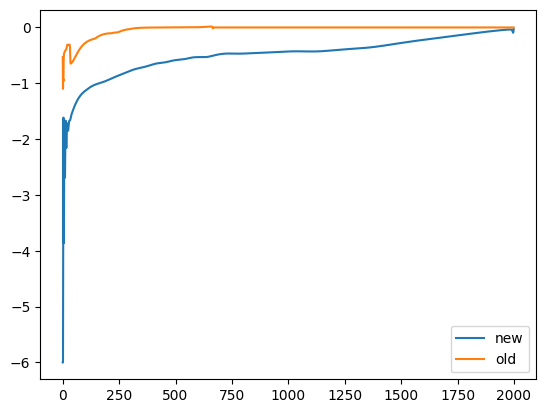

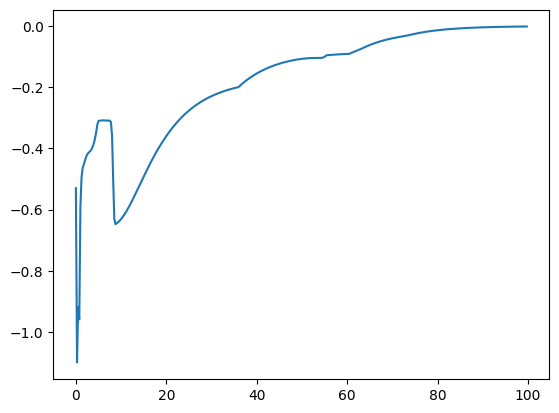

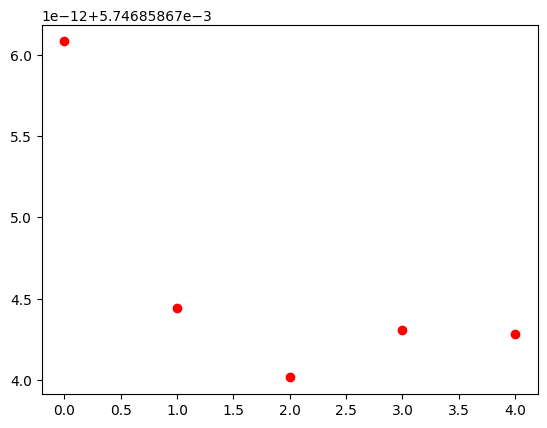

In [4]:
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

t_prot=500

#'results/zero_control_lowercoupling/dt=0.25_ps=-8.0_tcut=30_alpha=0.05/{0}ps'
#folder='results/zero_control/{0}ps/optimization_simplemodel_{0}ps/dt=0.25_ps=-8.0_tcut=500'
#with open('results/zero_control/{0}ps/optimization_simplemodel_{0}ps'.format(t_prot), 'rb') as f:

with open('results/zero_control_lower_coupling/dt=0.25_ps=-8.0_tcut=500_analyt/500ps', 'rb') as f:
    opt_dict_old = dill.load(f)

with open('results/zero_control/{0}ps/optimization_simplemodel_{0}ps_lowerbound/dt=0.25_ps=-8.0_tcut=500/500ps', 'rb') as f:
    opt_dict = dill.load(f)

plt.plot(2*opt_dict['result'].x[0::3],label='new')
plt.plot(opt_dict_old['result'].x[0::3],label='old')
plt.legend()
plt.show()

opt_control = opt_dict_old['result'].x[0::3]
dt_control = t_prot / len(opt_control)
control_times = np.linspace(0, t_prot, len(opt_control), endpoint=False)

delta_t = interp1d(control_times, opt_control, kind='previous', fill_value="extrapolate")

plt.plot(control_times[:400], opt_control[:400])
plt.show()

num_its=np.shape(opt_dict['log'])
heat_log=[opt_dict['log'][i]['final heat'] for i in range(num_its[0])]

num_its=np.shape(opt_dict_old['log'])
heat_log_old=[opt_dict_old['log'][i]['final heat'] for i in range(num_its[0])]
#plt.plot(heat_log)
plt.plot(heat_log_old[20:25],'ro')
plt.show()

In [14]:
def hamiltonian_t(t):
    return delta_t(t)*oqupy.operators.sigma("x")/2 #if analytic propagators used no fcator of 0.5

system = oqupy.TimeDependentSystem(hamiltonian_t)

dict_keys(['result', 'log', 'fidelitygrad', 'opttime', 'parameters'])


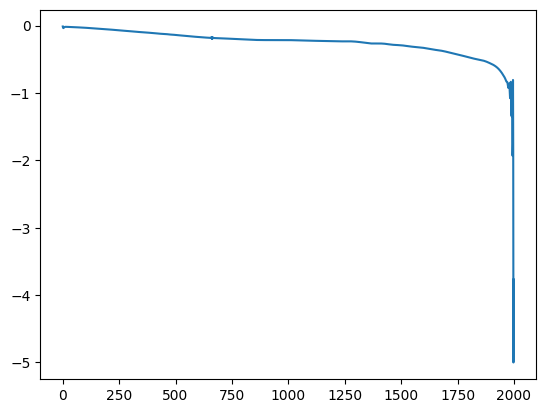

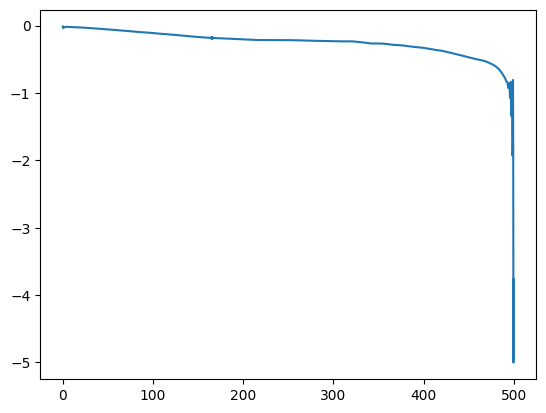

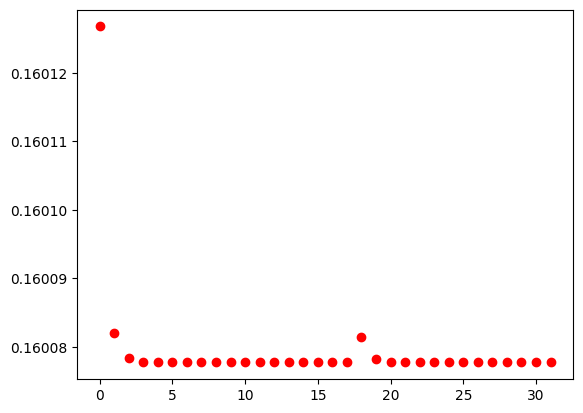

In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

t_prot=500

with open('results'.format(t_prot), 'rb') as f:
    opt_dict = dill.load(f)
print(opt_dict.keys())
plt.plot(opt_dict['result'].x[0::3])
plt.show()

opt_control = opt_dict['result'].x[0::3]
dt_control = t_prot / len(opt_control)
control_times = np.linspace(0, t_prot, len(opt_control), endpoint=False)

delta_t = interp1d(control_times, opt_control, kind='previous', fill_value="extrapolate")

plt.plot(control_times, opt_control)
plt.show()

num_its=np.shape(opt_dict['log'])
heat_log=[opt_dict['log'][i]['final heat'] for i in range(10,num_its[0])]
plt.plot(heat_log,'ro')
plt.show()

0.25
500
2000
--> Compute dynamics:


100.0% 2000 of 2000 [########################################] 00:02:06
Elapsed time: 126.0s
--> Compute dynamics:
100.0% 2000 of 2000 [########################################] 00:02:13
Elapsed time: 133.0s


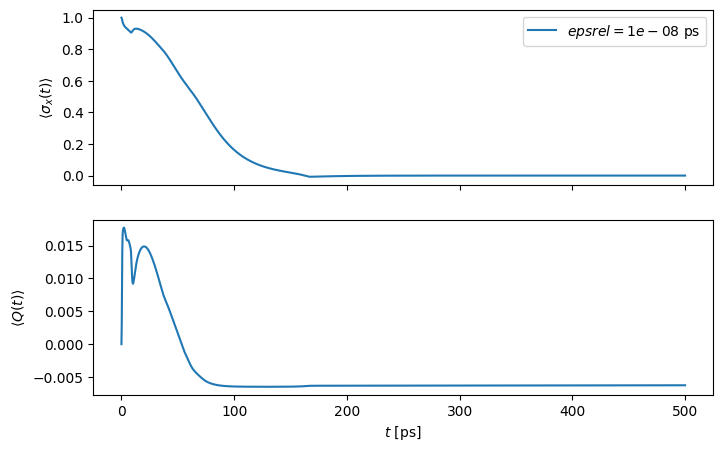

In [67]:
fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
num_steps = int(t_prot/dt)
print(dt)
print(t_prot)
def hamiltonian_t(t):
    return delta_t(t)*oqupy.operators.sigma("x")/2
print(num_steps)
system = oqupy.TimeDependentSystem(hamiltonian_t)

dynamics = oqupy.compute_dynamics(
    process_tensor=processtensor,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamicscf = oqupy.compute_dynamics(
    process_tensor=processtensorcf,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

t,final_x = dynamics.expectations(op.sigma('x'), real=True)
final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
axs[0].plot(t,final_x,'-',label=r'$epsrel={0}$ ps'.format(epsrel))
axs[1].plot(t,final_Q,'-')

axs[0].legend()
axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
axs[1].set_xlabel(r'$ t$ [ps]')

plt.show()

In [102]:

# define bath frequencies and couplings
omega_k = np.linspace(0.01, 5*omega_cutoff, 200)  # discretized modes
J = 2 * np.pi * alpha * omega_k * np.exp(-omega_k / omega_cutoff)
g_k = np.sqrt(J * (omega_k[1]-omega_k[0]) / np.pi)

dt = t[1] - t[0]
b_k = np.zeros((len(omega_k), len(t)), dtype=complex)

for i, omega in enumerate(omega_k):
    kernel = np.exp(-1j * omega * (t[:, None] - t[None, :]))
    kernel = np.triu(kernel)  # enforce causal integration
    b_k[i] = -1j * g_k[i] * np.sum(kernel * final_x[None, :] * dt, axis=1)

# real-space displacement (position quadrature)
x_k = b_k + b_k.conj()

# at final time:
x_final = np.real(x_k[:, -1])


ValueError: operands could not be broadcast together with shapes (2000,2000) (1,2001) 

  1.5%   29 of 2000 [----------------------------------------] 08:35:04

  1.5%   29 of 2000 [----------------------------------------] 08:35:21

In [ ]:

# Given:
# t: time array (shape N)
# s_t: expectation value of system operator <s(t)> (shape N)
# alpha, omega_c: bath parameters
# t_final: final time of interest

# Parameters
omega_k = np.linspace(0.01, 5 * omega_cutoff, 200)  # bath frequencies
J = 2 * np.pi * alpha * omega_k * np.exp(-omega_k / omega_cutoff)  # Ohmic SD
dt = t[1] - t[0]

# Compute the time integral for each frequency
# f(omega,t) = -2i * J(omega) ∫_0^t e^{-i ω (t - t')} s(t') dt'
f_omega_t = np.zeros((len(omega_k), len(t)), dtype=complex)

for i, omega in enumerate(omega_k):
    # causal kernel for each omega
    kernel = np.exp(-1j * omega * (t[:, None] - t[None, :]))
    kernel = np.triu(kernel)  # ensure t' <= t
    f_omega_t[i] = -2j * J[i] * np.sum(kernel * final_x[None, :] * dt, axis=1)




ValueError: operands could not be broadcast together with shapes (2000,2000) (1,2001) 

  1.5%   29 of 2000 [----------------------------------------] 08:35:03

200
0.00919685684484223
200
0.25644838727302494
200
0.044010252827551104


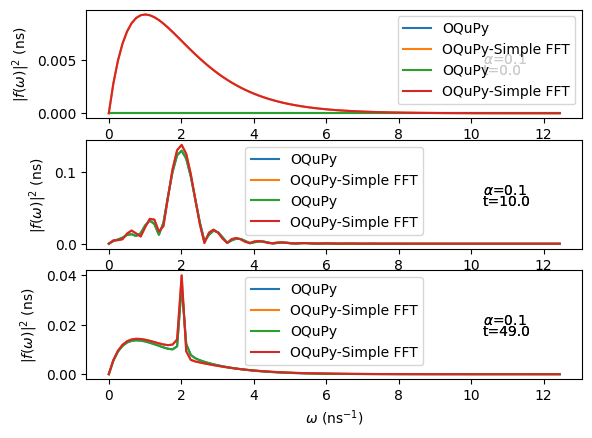

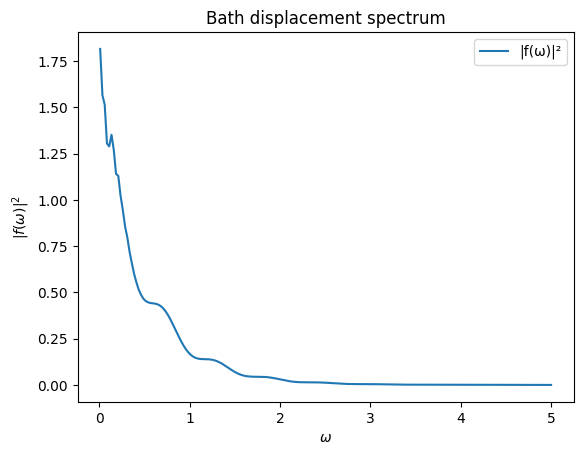

  1.5%   29 of 2000 [----------------------------------------] 02:51:28

In [ ]:
plt.sca(ax[0])
plotdispl2(0,200)
plt.sca(ax[1])
plotdispl2(10,200)
plt.sca(ax[2])
plotdispl2(49,200)
plt.show()

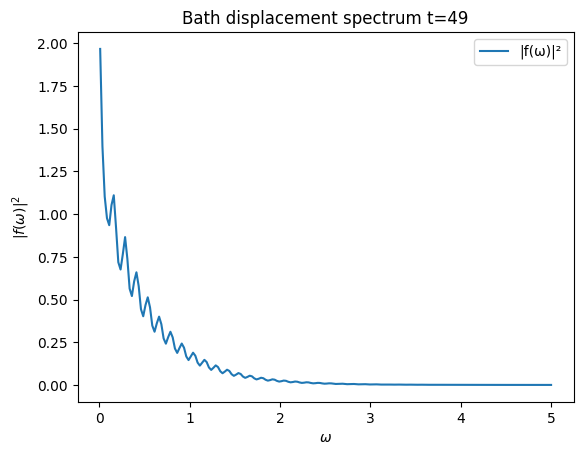

  1.5%   29 of 2000 [----------------------------------------] 02:56:16

In [ ]:
# Spectrum at the final time
f_final = f_omega_t[:, int(49/dt)]
spectrum = np.abs(f_final)**2

# Plot
plt.figure()
plt.plot(omega_k, spectrum, label='|f(ω)|²')
plt.xlabel(r'$\omega$')
plt.ylabel(r'$|f(\omega)|^2$')
plt.title('Bath displacement spectrum t=49')
plt.legend()
plt.show()

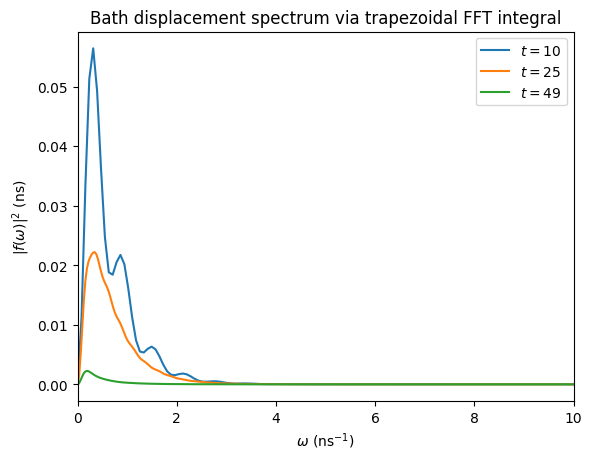

  1.5%   29 of 2000 [----------------------------------------] 04:14:27

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# --- Copied helper functions (unchanged) ---
def w(theta):
    if np.abs(theta) < 0.1:
        return 1.0 - theta**2 / 12 + theta**4 / 360 - theta**6 / 20160
    else:
        return 2 * (1 - np.cos(theta)) / (theta**2)

def alpha0(theta):
    if np.abs(theta) < 0.1:
        return -0.5 + theta**2 / 24 - theta**4 / 720 + theta**6 / 40320 + \
            1.0j * theta * (1.0 / 6.0 - theta**2 / 120 + theta**4 / 5040 - theta**6 / 362880)
    else:
        return -(1 - np.cos(theta)) / (theta**2) + 1.0j * (theta - np.sin(theta)) / (theta**2)

def trapezoidal_fft_integral(samples, a, delta, n):
    m = samples.shape[0] - 1
    assert n >= (m + 1)
    if n % 2 == 1:
        n = n + 1
    thetas = np.fft.fftfreq(n) * 2 * np.pi
    omegas = thetas / delta
    ws = np.vectorize(w)(thetas)
    a0s = np.vectorize(alpha0)(thetas)
    dftres = np.fft.ifft(samples, n=n, norm="forward")
    dftres = delta * np.exp(1.0j * omegas * a) * (
        dftres * ws + a0s * samples[0] + np.conjugate(a0s) * samples[m] * np.exp(1.0j * omegas * (m * delta - a))
    )
    return omegas, dftres


# --- Bath displacement computation using the FFT integral ---
def bath_displacement_spectrum_fft(t, s_t, alpha, omega_c, t_eval=None, natten=200, nfft=None):
    """
    Compute bath displacement spectrum |f(ω)|² using the same trapezoidal FFT integration method.
    """
    if t_eval is None:
        t_eval = t[-1]
    dt = t[1] - t[0]
    n_eval = int(t_eval / dt)
    
    # Apply attenuation window (as in plotdispl2)
    attenfactor = np.exp(np.arange(-n_eval, 1) / natten)
    s_t_windowed = s_t[:n_eval + 1] * attenfactor

    # Choose FFT length
    if nfft is None:
        nfft = 8 * len(s_t_windowed)  # oversampling for smoother ω grid
    
    # Compute Fourier integral ∫₀ᵗ e^{+iω(t−t′)} s(t′) dt′ via trapezoidal FFT
    omegas, F_omegas = trapezoidal_fft_integral(s_t_windowed[::-1], 0.0, dt, nfft)
    
    # Unscramble to normal frequency order
    omegas = np.fft.fftshift(omegas)
    F_omegas = np.fft.fftshift(F_omegas)

    # Shift to match phase convention (t−t′)
    phase = np.exp(1j * omegas * t_eval)
    F_omegas *= phase

    # Ohmic spectral density
    J = 2 * alpha * np.abs(omegas) * np.exp(-np.abs(omegas) / omega_c)

    # Compute displacement f(ω)
    f_omega = -2j * J * F_omegas

    # Spectrum
    spectrum = np.abs(f_omega)**2

    return omegas, spectrum, f_omega


# --- Example usage ---
if __name__ == "__main__":
    # Dummy test data
    t = np.linspace(0, 50, 2000)
    s_t = final_x
    alpha = 0.1
    omega_c = 1

    for t_eval in [10, 25, 49]:
        omegas, spec, _ = bath_displacement_spectrum_fft(t, s_t, alpha, omega_c, t_eval=t_eval)
        plt.plot(omegas, spec, label=fr"$t={t_eval}$")

    plt.xlim(0, 10)
    plt.xlabel(r'$\omega$ (ns$^{-1}$)')
    plt.ylabel(r'$|f(\omega)|^2$ (ns)')
    plt.title("Bath displacement spectrum via trapezoidal FFT integral")
    plt.legend()
    plt.show()


  1.5%   29 of 2000 [----------------------------------------] 02:59:50

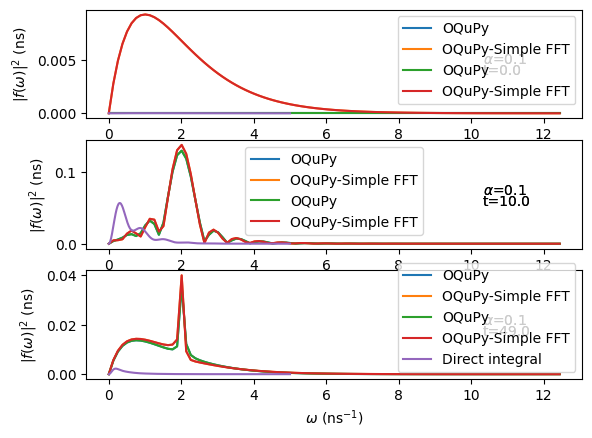

  1.5%   29 of 2000 [----------------------------------------] 03:02:45

In [ ]:
plt.sca(ax[0])
omega_k, spec0, _ = bath_displacement_spectrum(t, s_t, alpha, omega_c, t_eval=0)
plt.plot(omega_k, spec0, label='Direct integral')

plt.sca(ax[1])
omega_k, spec10, _ = bath_displacement_spectrum(t, s_t, alpha, omega_c, t_eval=10)
plt.plot(omega_k, spec10, label='Direct integral')

plt.sca(ax[2])
omega_k, spec49, _ = bath_displacement_spectrum(t, s_t, alpha, omega_c, t_eval=49)
plt.plot(omega_k, spec49, label='Direct integral')

plt.legend()
plt.show()
